Defining the domain

In [1]:
 #Defining $\sigma^* $
import numpy as np
import matplotlib.pyplot as plt
import torch

# grid resolution
N = 100

x = np.linspace(-0.5, 0.5, N)
y = np.linspace(-0.5, 0.5, N)
X, Y = np.meshgrid(x, y)

#Defining the domain and bondary


# domain limits
xmin, xmax = -0.5, 0.5
ymin, ymax = -0.5, 0.5

# grid spacing
hx = (xmax - xmin) / (N - 1)
hy = (ymax - ymin) / (N - 1)

# 1D grids
x = np.linspace(xmin, xmax, N)
y = np.linspace(ymin, ymax, N)

# 2D mesh
X, Y = np.meshgrid(x, y)

Defining boundary

In [2]:
# Collect boundary grid points (ordered clockwise, no duplicate corners)
# Domain: square [-0.5, 0.5]^2 with grid spacing hx, hy from (x, y)

boundary_x = []
boundary_y = []

# 1. Bottom edge: left → right (y = ymin)
boundary_x.extend(x)
boundary_y.extend([ymin] * N)

# 2. Right edge: bottom → top (x = xmax), exclude corners already in bottom/top
boundary_x.extend([xmax] * (N - 2))
boundary_y.extend(y[1:-1])

# 3. Top edge: right → left (y = ymax)
boundary_x.extend(x[::-1])
boundary_y.extend([ymax] * N)

# 4. Left edge: top → bottom (x = xmin), exclude corners
boundary_x.extend([xmin] * (N - 2))
boundary_y.extend(y[-2:0:-1])

boundary_x = np.array(boundary_x)
boundary_y = np.array(boundary_y)

m = len(boundary_x)  # total boundary grid points
print("Total boundary points 4N-4:", m)

Total boundary points 4N-4: 396


Defining L-shape sigma

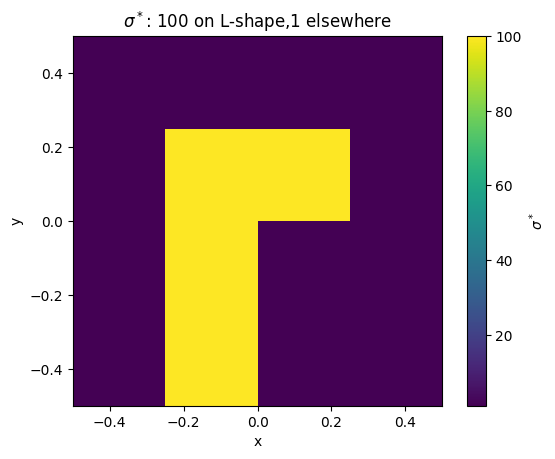

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 100

x = np.linspace(-0.5, 0.5, N)
y = np.linspace(-0.5, 0.5, N)
X, Y = np.meshgrid(x, y)

# σ* = 100 on L-shape, 0 elsewhere
def in_L(x, y):
    in_h = (-0.25 <= x) & (x <= 0.25) & (0 <= y) & (y <= 0.25)
    in_v = (-0.25 <= x) & (x <= 0) & (-0.5 <= y) & (y <= 0.25)
    return in_h | in_v

Sigma_star = np.where(in_L(X, Y), 100.0, 1.0)

plt.figure()
plt.imshow(Sigma_star, extent=[xmin, xmax, ymin, ymax], origin='lower')
plt.colorbar(label=r"$\sigma^*$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$\sigma^*$: 100 on L-shape,1 elsewhere")
plt.gca().set_aspect("equal")
plt.show()

Uniform placement of source and censors

In [4]:
# Every boundary grid point is either a source or a receiver; uniform and alternating (source → receiver → source → ...)
# m = 4*N - 4 total boundary points

m = len(boundary_x)  # 4*N - 4

n1_idx = np.arange(0, m, 2)   # sources at even boundary indices
n2_idx = np.arange(1, m, 2)   # receivers at odd boundary indices

n1 = len(n1_idx)
n2 = len(n2_idx)
n1_x = boundary_x[n1_idx]
n1_y = boundary_y[n1_idx]
n2_x = boundary_x[n2_idx]
n2_y = boundary_y[n2_idx]

assert n1 + n2 == m
assert len(np.intersect1d(n1_idx, n2_idx)) == 0

print("Number of sources (n_1):", n1)
print("Number of receivers (n_2):", n2)

Number of sources (n_1): 198
Number of receivers (n_2): 198


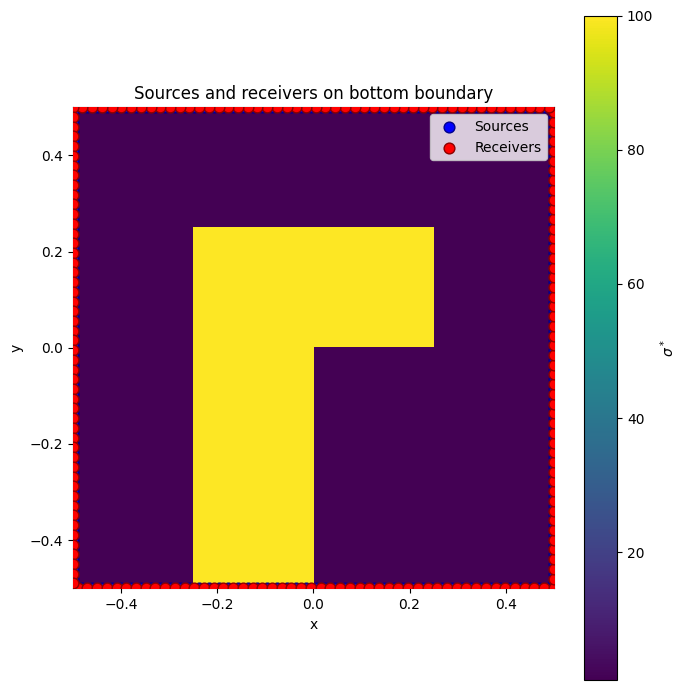

In [5]:
import numpy as np
import matplotlib.pyplot as plt

xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect("equal")

# Background: σ*
ax.imshow(Sigma_star, extent=[xmin, xmax, ymin, ymax], origin="lower", cmap="viridis")
plt.colorbar(ax.images[0], ax=ax, label=r"$\sigma^*$")

# Receivers = blue, Sensors = red
ax.scatter(n1_x, n1_y, c="blue", s=60, zorder=3, label="Sources", edgecolors="darkblue")
ax.scatter(n2_x, n2_y, c="red", s=60, zorder=3, label="Receivers", edgecolors="darkred")

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Sources and receivers on bottom boundary")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Building F and G

In [6]:
# F: n_1 × m — row i is delta at source i (1 at boundary index n1_idx[i])
F = np.zeros((n1, m))
for i in range(n1):
    F[i, n1_idx[i]] = 1.0

# G: n_2 × m — row j is delta at receiver j (1 at boundary index n2_idx[j])
G = np.zeros((n2, m))
for j in range(n2):
    G[j, n2_idx[j]] = 1.0

print("F shape:", F.shape, "  G shape:", G.shape)

F shape: (198, 396)   G shape: (198, 396)


Finite element solve for F and G

In [7]:
# FEM solver for your setup: L-shaped σ*, boundary m = 4*N-4, F and G (e.g. 12×m)
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
h = (xmax - xmin) / (N - 1)
x = np.linspace(xmin, xmax, N)
y = np.linspace(ymin, ymax, N)
nodes = np.array([(x[i], y[j]) for j in range(N) for i in range(N)])
n_nodes = N * N

def idx(i, j):
    return j * N + i

triangles = []
for j in range(N - 1):
    for i in range(N - 1):
        n1, n2 = idx(i, j), idx(i + 1, j)
        n3, n4 = idx(i, j + 1), idx(i + 1, j + 1)
        triangles.append([n1, n2, n4])
        triangles.append([n1, n4, n3])

A = sp.lil_matrix((n_nodes, n_nodes))
for tri in triangles:
    pts = nodes[tri]
    x0, x1, x2 = pts
    B = np.array([[x1[0]-x0[0], x2[0]-x0[0]], [x1[1]-x0[1], x2[1]-x0[1]]])
    area = abs(np.linalg.det(B)) / 2
    C = np.linalg.inv(B).T
    grads = np.array([[-1, -1], [1, 0], [0, 1]]) @ C
    center = pts.mean(axis=0)
    ic = int(round((center[0] - xmin) / h))
    jc = int(round((center[1] - ymin) / h))
    ic, jc = np.clip(ic, 0, N - 1), np.clip(jc, 0, N - 1)
    sigma = Sigma_star[jc, ic]
    for a in range(3):
        for b in range(3):
            A[tri[a], tri[b]] += sigma * area * np.dot(grads[a], grads[b])
A = A.tocsr()

boundary_ij = (
    [(i, 0) for i in range(N)]
    + [(N - 1, j) for j in range(1, N - 1)]
    + [(i, N - 1) for i in range(N - 1, -1, -1)]
    + [(0, j) for j in range(N - 2, 0, -1)]
)
boundary_dofs = np.array([idx(i, j) for (i, j) in boundary_ij], dtype=np.int64)
m = len(boundary_dofs)  # 4*N - 4
interior = np.array([k for k in range(n_nodes) if k not in set(boundary_dofs)], dtype=np.int64)

Aii = A[interior][:, interior]
Aib = A[interior][:, boundary_dofs]
solve_II = spla.splu(Aii).solve

def solve_one_bc(bc_vals):
    bc_vals = np.asarray(bc_vals, dtype=np.float64).flatten()
    rhs = -Aib @ bc_vals
    uI = solve_II(rhs)
    u = np.zeros(n_nodes)
    u[interior] = uI
    u[boundary_dofs] = bc_vals
    return u.reshape(N, N)

# F, G must be (n1, m) and (n2, m) with m = 4*N-4
assert F.shape[1] == m and G.shape[1] == m, "F and G must have m columns (4*N-4)"
u_L_i_list = [solve_one_bc(F[i, :]) for i in range(F.shape[0])]
v_Lj_list = [solve_one_bc(G[j, :]) for j in range(G.shape[0])]
print("FEM: forward", len(u_L_i_list), "adjoint", len(v_Lj_list))
print(u_L_i_list[0].shape)

/tmp/ipykernel_2733369/1739997294.py:54: SparseEfficiencyWarning: splu converted its input to CSC format
  solve_II = spla.splu(Aii).solve


FEM: forward 198 adjoint 198
(100, 100)


Plot of the solutions 

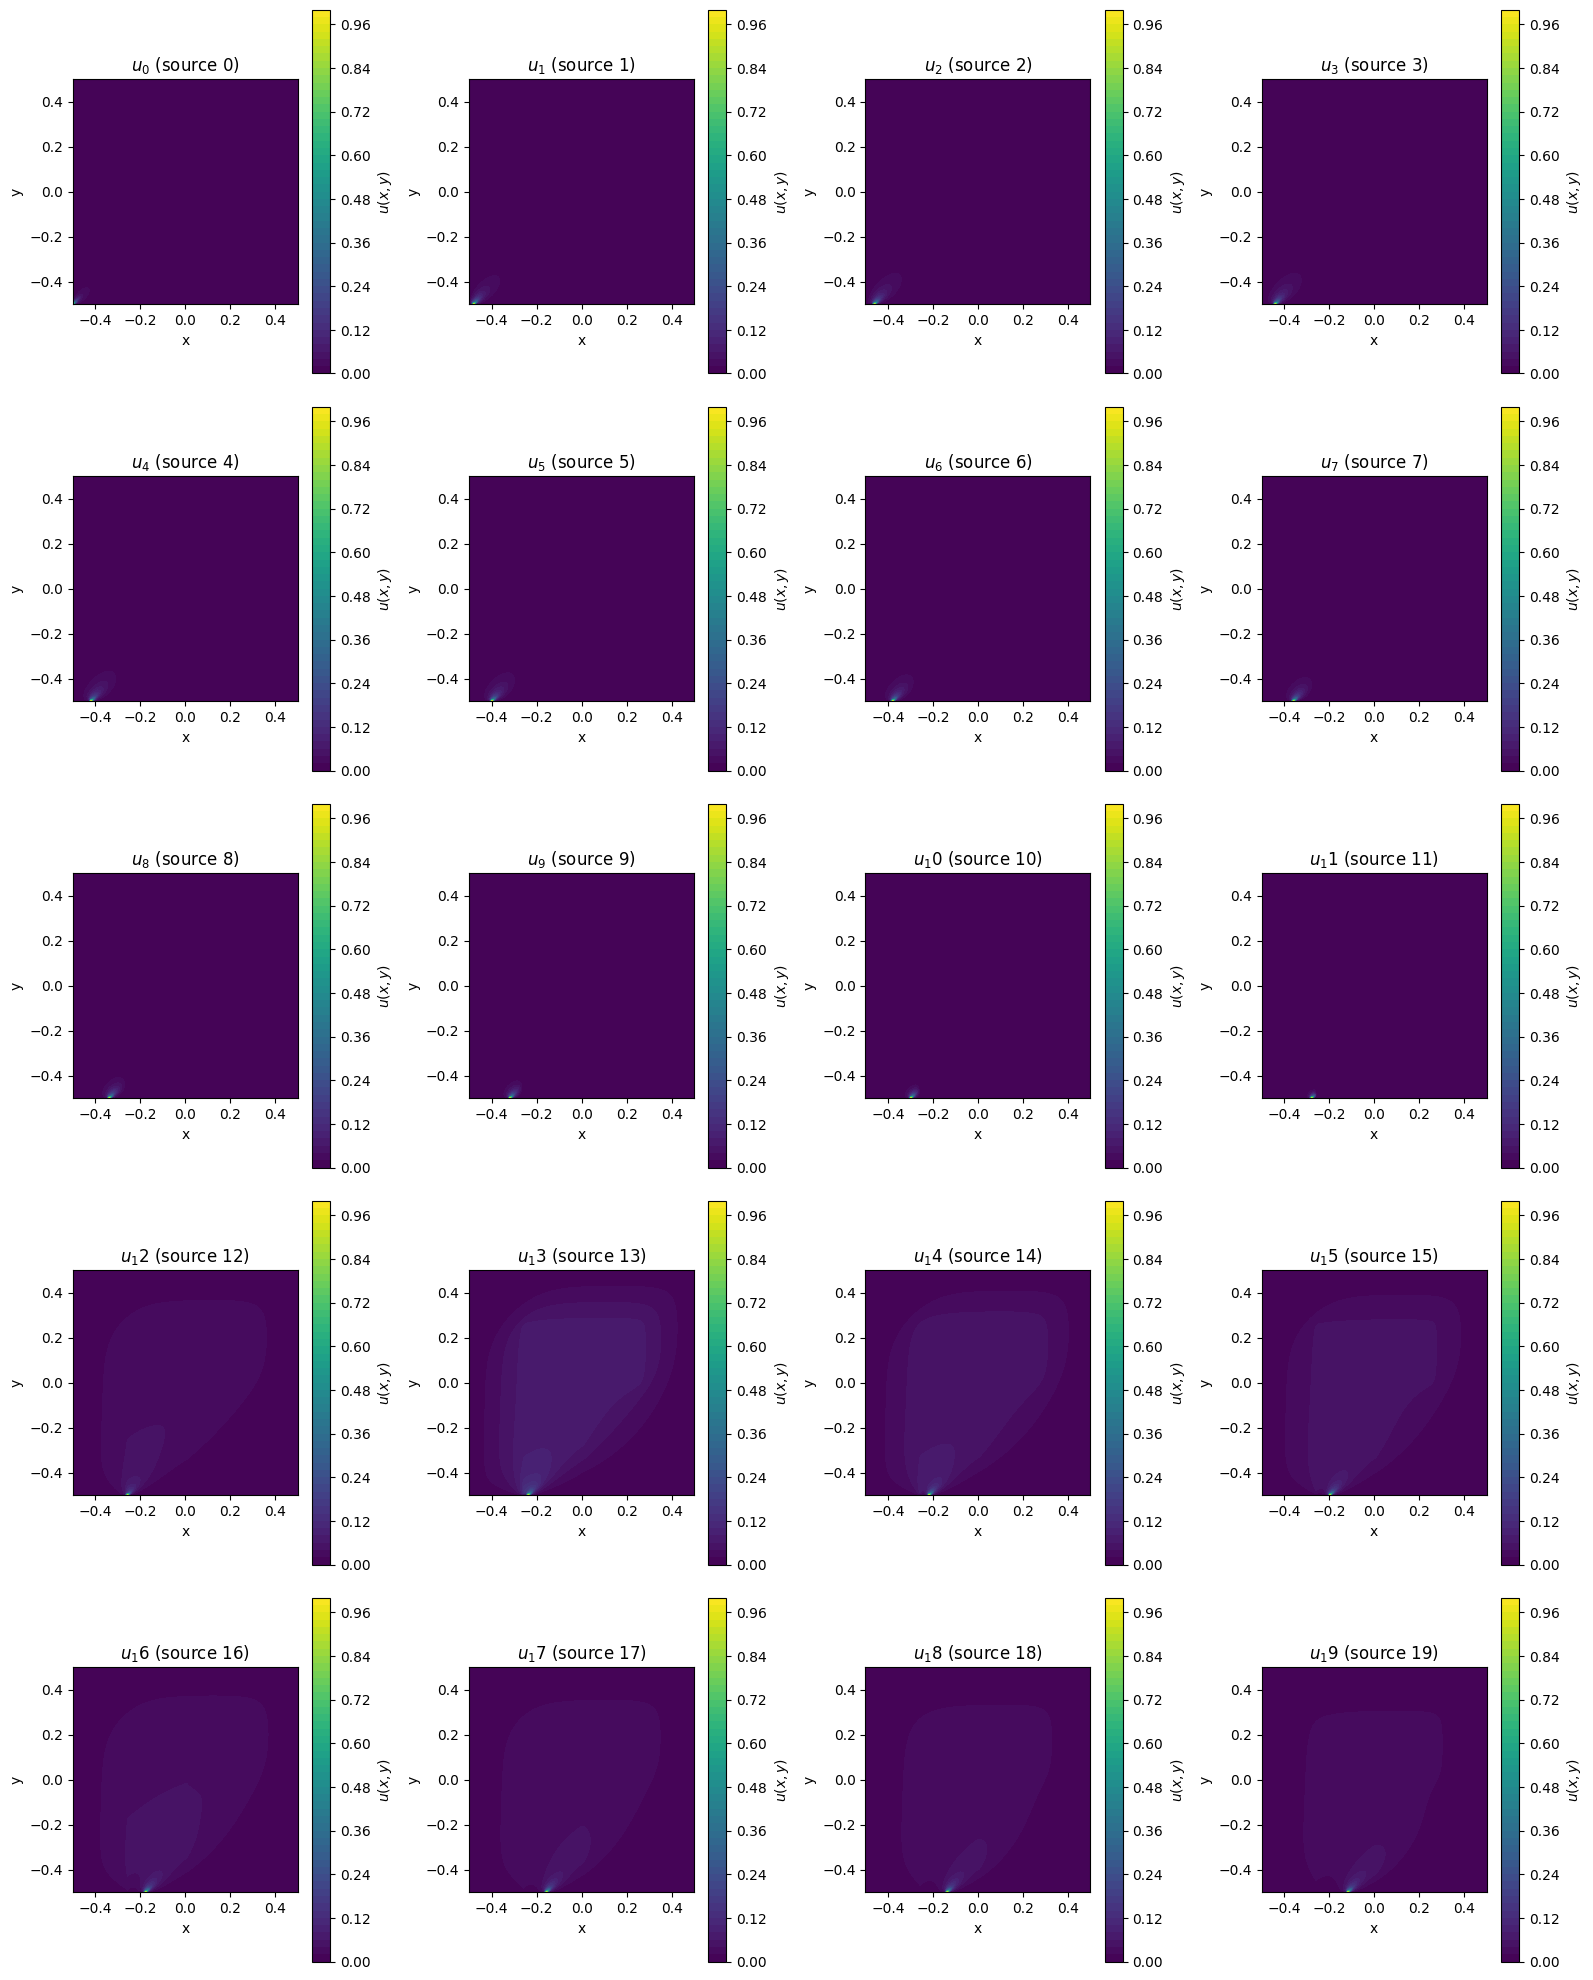

In [8]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

triang = mtri.Triangulation(nodes[:, 0], nodes[:, 1], triangles)

indices_to_show = np.arange(0, len(u_L_i_list), 10)  # [0, 4, 8, 12, ...]
n_show = len(indices_to_show)

n_cols = 4
n_rows = (n_show + n_cols - 1) // n_cols
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axs = np.atleast_2d(axs)
for idx in range(n_show):
    i, j = idx // n_cols, idx % n_cols
    u_flat = u_L_i_list[idx].flatten()
    cf = axs[i, j].tricontourf(triang, u_flat, levels=50)
    axs[i, j].set_title(r"$u_{}$ (source {})".format(idx, idx))
    axs[i, j].set_xlabel("x")
    axs[i, j].set_ylabel("y")
    axs[i, j].set_aspect("equal")
    plt.colorbar(cf, ax=axs[i, j], label=r"$u(x,y)$")
for idx in range(n_show, n_rows * n_cols):
    axs[idx // n_cols, idx % n_cols].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
n1, n2 = F.shape[0], G.shape[0]
m_grid = N * N
h = (xmax - xmin) / (N - 1)

def grad_2d(u):
    gx = np.zeros_like(u)
    gy = np.zeros_like(u)
    gx[1:-1, :] = (u[2:, :] - u[:-2, :]) / (2 * h)
    gx[0, :] = (u[1, :] - u[0, :]) / h
    gx[-1, :] = (u[-1, :] - u[-2, :]) / h
    gy[:, 1:-1] = (u[:, 2:] - u[:, :-2]) / (2 * h)
    gy[:, 0] = (u[:, 1] - u[:, 0]) / h
    gy[:, -1] = (u[:, -1] - u[:, -2]) / h
    return gx, gy

grad_u_x = np.array([grad_2d(u_L_i_list[i])[0] for i in range(n1)])
grad_u_y = np.array([grad_2d(u_L_i_list[i])[1] for i in range(n1)])
grad_v_x = np.array([grad_2d(v_Lj_list[j])[0] for j in range(n2)])
grad_v_y = np.array([grad_2d(v_Lj_list[j])[1] for j in range(n2)])

A = np.zeros((n1 * n2, m_grid))
for ii in range(N):
    for jj in range(N):
        k = ii * N + jj
        U_at_k = np.stack([grad_u_x[:, ii, jj], grad_u_y[:, ii, jj]], axis=1)
        V_at_k = np.stack([grad_v_x[:, ii, jj], grad_v_y[:, ii, jj]], axis=1)
        A[:, k] = (U_at_k @ V_at_k.T).ravel()
A = A / N

print("A shape:", A.shape)

A shape: (39204, 10000)


Define $$sigma = sigma_star + delta_sigma$$ compute u^* and normal derivatives

In [21]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ------------------------------------------------------------
# 1) Define Sigma = Sigma_star + delta_sigma
#    delta_sigma = 1e-3 on [-0.2,0] x [-0.2,0], 0 elsewhere
# ------------------------------------------------------------
xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
h = (xmax - xmin) / (N - 1)

x = np.linspace(xmin, xmax, N)
y = np.linspace(ymin, ymax, N)
X, Y = np.meshgrid(x, y)

delta_sigma_const = 1e-3
support = (-0.2 <= X) & (X <= 0.0) & (-0.2 <= Y) & (Y <= 0.0)

delta_sigma = np.where(support, delta_sigma_const, 0.0).astype(np.float64)
Sigma = Sigma_star + delta_sigma

print("fraction support (square):", float(np.mean(support)))
print("delta_sigma min/max:", delta_sigma.min(), delta_sigma.max())
print("Sigma min/max:", Sigma.min(), Sigma.max())

# ------------------------------------------------------------
# 2) FEM utilities (same grid/order as before)
# ------------------------------------------------------------
nodes = np.array([(x[i], y[j]) for j in range(N) for i in range(N)])
n_nodes = N * N

def idx(i, j):
    return j * N + i

# triangles (2 per cell)
triangles = []
for j in range(N - 1):
    for i in range(N - 1):
        n1_, n2_ = idx(i, j), idx(i + 1, j)
        n3_, n4_ = idx(i, j + 1), idx(i + 1, j + 1)
        triangles.append([n1_, n2_, n4_])
        triangles.append([n1_, n4_, n3_])

# boundary dof ordering must match boundary_x / boundary_y and F,G columns
boundary_ij = (
    [(i, 0) for i in range(N)]
    + [(N - 1, j) for j in range(1, N - 1)]
    + [(i, N - 1) for i in range(N - 1, -1, -1)]
    + [(0, j) for j in range(N - 2, 0, -1)]
)
boundary_dofs = np.array([idx(i, j) for (i, j) in boundary_ij], dtype=np.int64)

m_bd = len(boundary_x)
assert len(boundary_dofs) == m_bd
assert F.shape[1] == m_bd and G.shape[1] == m_bd

is_boundary = np.zeros(n_nodes, dtype=bool)
is_boundary[boundary_dofs] = True
interior = np.where(~is_boundary)[0]

def assemble_K_from_sigma(sigma_grid):
    K = sp.lil_matrix((n_nodes, n_nodes))
    for tri in triangles:
        pts = nodes[tri]
        x0, x1, x2 = pts
        B = np.array([
            [x1[0] - x0[0], x2[0] - x0[0]],
            [x1[1] - x0[1], x2[1] - x0[1]],
        ])
        area = abs(np.linalg.det(B)) / 2.0
        C = np.linalg.inv(B).T
        grads = np.array([[-1, -1], [1, 0], [0, 1]]) @ C

        center = pts.mean(axis=0)
        ic = int(round((center[0] - xmin) / h))
        jc = int(round((center[1] - ymin) / h))
        ic = np.clip(ic, 0, N - 1)
        jc = np.clip(jc, 0, N - 1)
        sigma_val = sigma_grid[jc, ic]

        for a in range(3):
            for b in range(3):
                K[tri[a], tri[b]] += sigma_val * area * np.dot(grads[a], grads[b])
    return K.tocsr()

def solve_all_u_for_sigma(sigma_grid, Fmat):
    K = assemble_K_from_sigma(sigma_grid)
    Aii = K[interior][:, interior]
    Aib = K[interior][:, boundary_dofs]
    solve_II = spla.splu(Aii.tocsc()).solve

    def solve_one_bc(bc_vals):
        bc_vals = np.asarray(bc_vals, dtype=np.float64).flatten()
        rhs = -Aib @ bc_vals
        uI = solve_II(rhs)
        u = np.zeros(n_nodes, dtype=np.float64)
        u[interior] = uI
        u[boundary_dofs] = bc_vals
        return u.reshape(N, N)

    return [solve_one_bc(Fmat[i, :]) for i in range(Fmat.shape[0])]

# ------------------------------------------------------------
# 3) Solve u* (background) and u (perturbed Sigma) with same F
# ------------------------------------------------------------
u_star_i_list = solve_all_u_for_sigma(Sigma_star, F)  # u^*
u_i_list      = solve_all_u_for_sigma(Sigma, F)       # u

print("Solved u* count:", len(u_star_i_list), "Solved u count:", len(u_i_list))
print("Each solution shape:", u_i_list[0].shape)

# ------------------------------------------------------------
# 4) Normal derivative on boundary for u and u*
#    order: bottom -> right -> top(rev) -> left(rev)
# ------------------------------------------------------------
def boundary_dn_u(u):
    q = []

    # bottom: j=0, outward n=(0,-1): dn u = -du/dy
    j = 0
    for i in range(N):
        q.append(-(u[j+1, i] - u[j, i]) / h)

    # right: i=N-1, outward n=(1,0): dn u = du/dx
    i = N - 1
    for j in range(1, N - 1):
        q.append((u[j, i] - u[j, i-1]) / h)

    # top: j=N-1, outward n=(0,1): dn u = du/dy, i reversed
    j = N - 1
    for i in range(N - 1, -1, -1):
        q.append((u[j, i] - u[j-1, i]) / h)

    # left: i=0, outward n=(-1,0): dn u = -du/dx, j reversed
    i = 0
    for j in range(N - 2, 0, -1):
        q.append(-(u[j, i+1] - u[j, i]) / h)

    return np.asarray(q, dtype=np.float64)

dn_u_all      = np.array([boundary_dn_u(u) for u in u_i_list])       # shape (n1, m_bd)
dn_u_star_all = np.array([boundary_dn_u(u) for u in u_star_i_list])  # shape (n1, m_bd)

print("dn_u_all shape:", dn_u_all.shape)
print("dn_u_star_all shape:", dn_u_star_all.shape)

# ------------------------------------------------------------
# 5) Use G (receiver indices n2_idx) to sample receiver traces
# ------------------------------------------------------------
dn_u_recv      = dn_u_all[:, n2_idx]       # shape (n1, n2)
dn_u_star_recv = dn_u_star_all[:, n2_idx]  # shape (n1, n2)

print("Receiver-sampled dn(u) shape:", dn_u_recv.shape)
print("Receiver-sampled dn(u*) shape:", dn_u_star_recv.shape)

fraction support (square): 0.04
delta_sigma min/max: 0.0 0.001
Sigma min/max: 1.0 100.001


Solved u* count: 198 Solved u count: 198
Each solution shape: (100, 100)
dn_u_all shape: (198, 396)
dn_u_star_all shape: (198, 396)
Receiver-sampled dn(u) shape: (198, 198)
Receiver-sampled dn(u*) shape: (198, 198)


Plot the pertubation

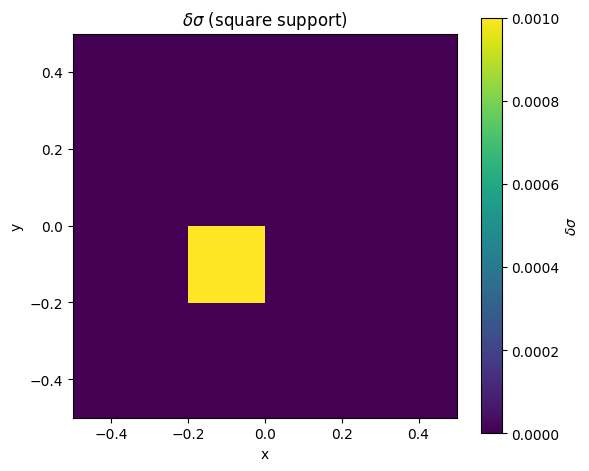

In [22]:
import matplotlib.pyplot as plt
import numpy as np

xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(delta_sigma, extent=[xmin, xmax, ymin, ymax],
               origin="lower", cmap="viridis")
plt.colorbar(im, ax=ax, label=r"$\delta\sigma$")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$ (square support)")
plt.tight_layout()
plt.show()

Assemble b

In [12]:
import numpy as np

# boundary sigma in the SAME boundary order:
# bottom -> right -> top(reversed) -> left(reversed)
def sigma_on_boundary(sigma_grid):
    vals = []

    # bottom: j=0, i=0..N-1
    j = 0
    for i in range(N):
        vals.append(sigma_grid[j, i])

    # right: i=N-1, j=1..N-2
    i = N - 1
    for j in range(1, N - 1):
        vals.append(sigma_grid[j, i])

    # top: j=N-1, i=N-1..0
    j = N - 1
    for i in range(N - 1, -1, -1):
        vals.append(sigma_grid[j, i])

    # left: i=0, j=N-2..1
    i = 0
    for j in range(N - 2, 0, -1):
        vals.append(sigma_grid[j, i])

    return np.asarray(vals, dtype=np.float64)

sigma_bd = sigma_on_boundary(Sigma)
sigma_star_bd = sigma_on_boundary(Sigma_star)

# sample at receiver locations (delta g_j)
sigma_recv = sigma_bd[n2_idx]             # (n2,)
sigma_star_recv = sigma_star_bd[n2_idx]   # (n2,)

# LHS data matrix: shape (n1, n2)
LHS_mat = dn_u_all[:, n2_idx] * sigma_recv[None, :] \
        - dn_u_star_all[:, n2_idx] * sigma_star_recv[None, :]

# Optional: uniform boundary spacing ds ≈ h
# LHS_mat = h * LHS_mat

b = LHS_mat.ravel()

print("LHS_mat shape:", LHS_mat.shape)
print("b shape:", b.shape)

LHS_mat shape: (198, 198)
b shape: (39204,)


Plot b

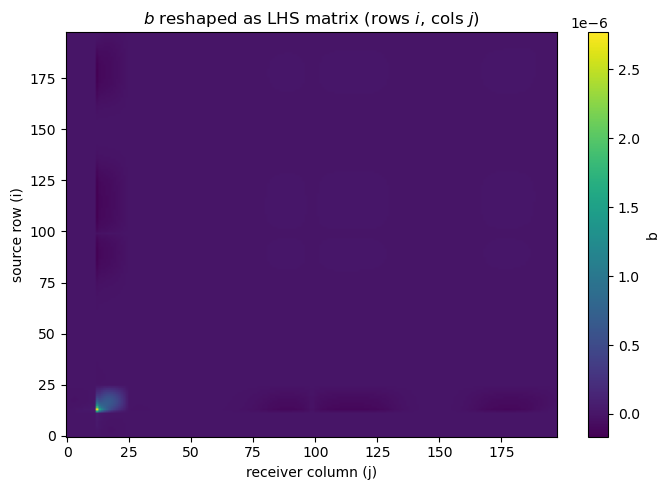

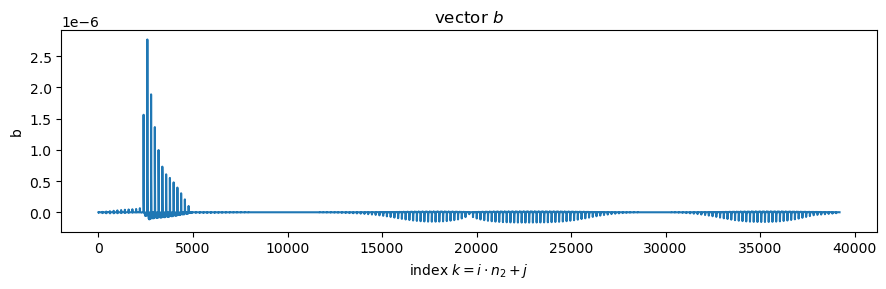

In [14]:
import matplotlib.pyplot as plt
import numpy as np

n1, n2 = LHS_mat.shape  # or LHS_mat.shape[0], LHS_mat.shape[1]

# --- 2D: same as LHS_mat ---
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    LHS_mat,
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
ax.set_xlabel("receiver column (j)")
ax.set_ylabel("source row (i)")
ax.set_title(r"$b$ reshaped as LHS matrix (rows $i$, cols $j$)")
plt.colorbar(im, ax=ax, label="b")
plt.tight_layout()
plt.show()

# --- 1D: b vs stacked index k = i * n2 + j ---
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(b)
ax.set_xlabel(r"index $k = i \cdot n_2 + j$")
ax.set_ylabel("b")
ax.set_title(r"vector $b$")
plt.tight_layout()
plt.show()

Solve using lasso

In [13]:
import numpy as np


def soft_threshold(x, t):
    return np.sign(x) * np.maximum(np.abs(x) - t, 0.0)


def lasso_ista(A, b, lambda_l1, max_iter=10000, tol=1e-6, verbose=False):
    """
    Lasso via ISTA:
        minimize 0.5 * ||A x - b||^2 + lambda_l1 * ||x||_1

    A: (m, n), b: (m,), lambda_l1 >= 0
    """
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64).ravel()
    m, n = A.shape
    assert b.shape[0] == m

    # Lipschitz constant of grad of 0.5||Ax-b||^2 is ||A||_2^2
    s_max = np.linalg.svd(A, compute_uv=False)[0]
    L = float(s_max ** 2)
    if L <= 0:
        L = 1.0
    step = 1.0 / L

    x = np.zeros(n, dtype=np.float64)
    for it in range(max_iter):
        grad = A.T @ (A @ x - b)
        x_new = soft_threshold(x - step * grad, lambda_l1 * step)
        dx = np.linalg.norm(x_new - x)
        if dx < tol * (np.linalg.norm(x_new) + 1e-12):
            if verbose:
                print("ISTA converged at iter", it + 1)
            break
        x = x_new
    return x


def lasso_fista(A, b, lambda_l1, max_iter=10000, tol=1e-6, verbose=False):
    """
    Same objective as lasso_ista, using FISTA (often fewer iterations).
    """
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64).ravel()
    m, n = A.shape
    assert b.shape[0] == m

    s_max = np.linalg.svd(A, compute_uv=False)[0]
    L = float(s_max ** 2)
    if L <= 0:
        L = 1.0
    step = 1.0 / L

    x = np.zeros(n, dtype=np.float64)
    y = x.copy()
    t = 1.0
    for it in range(max_iter):
        grad = A.T @ (A @ y - b)
        x_new = soft_threshold(y - step * grad, lambda_l1 * step)
        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        y = x_new + ((t - 1.0) / t_new) * (x_new - x)
        if np.linalg.norm(x_new - x) < tol * (np.linalg.norm(x_new) + 1e-12):
            if verbose:
                print("FISTA converged at iter", it + 1)
            break
        x, t = x_new, t_new
    return x


# --- use ---
lambda_l1 = 1   # increase → sparser / smaller coeffs; decrease → better fit
x = lasso_fista(A, b, lambda_l1, verbose=True)

r = A @ x - b
print("||Ax - b|| / ||b||:", np.linalg.norm(r) / (np.linalg.norm(b) + 1e-300))
print("||x||_1:", np.linalg.norm(x, ord=1))

FISTA converged at iter 1
||Ax - b|| / ||b||: 1.0
||x||_1: 0.0


In [16]:
import numpy as np
from sklearn.linear_model import Lasso


# If you want penalty λ||x||_1 on ||b - A x||^2 (informal), use alpha = λ / (2*m)
lam_l1 = 1e-7   # tune

model = Lasso(alpha=lam_l1, fit_intercept=False, max_iter=10000, tol=1e-9)
model.fit(A, b)
x = model.coef_

# optional: misfit
print("relative residual ||Ax - b|| / ||b||:",
      np.linalg.norm(A @ x - b) / (np.linalg.norm(b) + 1e-300))

relative residual ||Ax - b|| / ||b||: 1.0


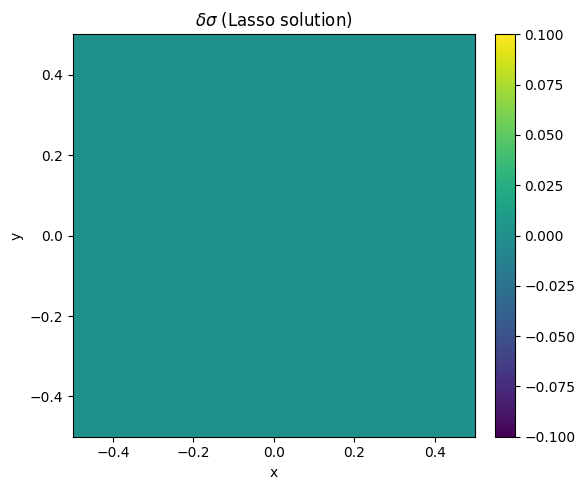

min / max: 0.0 0.0


In [14]:
import matplotlib.pyplot as plt
import numpy as np

delta_sigma = x.reshape(N, N)
xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$ (Lasso solution)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("min / max:", float(delta_sigma.min()), float(delta_sigma.max()))

try L2\Tikhonov regularization 

In [15]:
import numpy as np

A = np.asarray(A, dtype=np.float64)
b = np.asarray(b, dtype=np.float64).ravel()
m, n = A.shape
assert b.shape[0] == m

lam_l2 = 1e-9   # tune: larger → smaller ||x||, smoother; smaller → tighter fit to b

ATb = A.T @ b
M = A.T @ A + lam_l2 * np.eye(n, dtype=np.float64)
x_l2 = np.linalg.solve(M, ATb)

# diagnostics
res = A @ x_l2 - b
print("lambda:", lam_l2)
print("||Ax - b|| / ||b||:", np.linalg.norm(res) / (np.linalg.norm(b) + 1e-300))
print("||x||:", np.linalg.norm(x_l2))

lambda: 1e-09
||Ax - b|| / ||b||: 0.016060002677216186
||x||: 37.800591557010655


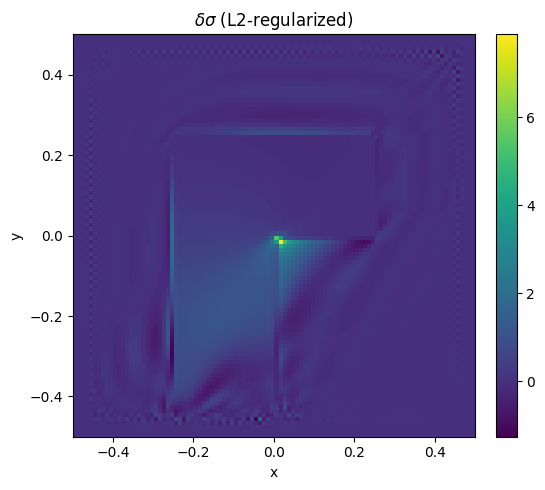

min / max: -1.266127362357953 7.878969940829657


In [20]:
import numpy as np
import matplotlib.pyplot as plt

delta_sigma_l2 = x_l2.reshape(N, N)
xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$ (L2-regularized)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("min / max:", float(delta_sigma_l2.min()), float(delta_sigma_l2.max()))

Let's try total variation 

In [18]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import LinearOperator, cg

# --- inputs ---
A = np.asarray(A, dtype=np.float64)
b = np.asarray(b, dtype=np.float64).ravel()
m, n = A.shape
assert b.shape[0] == m and n == N * N

lam_tv = 1e-3
rho = 1.0
max_admm = 100
tol_admm = 1e-4
cg_tol = 1e-5
cg_maxiter = 150

# --- sparse forward-difference operator D (2N(N-1) x N^2) ---
def make_gradient_operator(N: int) -> sparse.csr_matrix:
  n = N * N
  nrow = 2 * N * (N - 1)
  rows = np.empty(2 * nrow, dtype=np.int64)
  cols = np.empty(2 * nrow, dtype=np.int64)
  vals = np.empty(2 * nrow, dtype=np.float64)

  # x-direction differences
  k = 0
  r = 0
  for jj in range(N):
    for ii in range(N - 1):
      k0 = ii * N + jj
      k1 = (ii + 1) * N + jj
      rows[k:k+2] = r
      cols[k:k+2] = [k1, k0]
      vals[k:k+2] = [1.0, -1.0]
      k += 2
      r += 1

  # y-direction differences
  for ii in range(N):
    for jj in range(N - 1):
      k0 = ii * N + jj
      k1 = ii * N + (jj + 1)
      rows[k:k+2] = r
      cols[k:k+2] = [k1, k0]
      vals[k:k+2] = [1.0, -1.0]
      k += 2
      r += 1

  return sparse.csr_matrix((vals, (rows, cols)), shape=(nrow, n))

def soft_threshold(v, kappa):
  return np.sign(v) * np.maximum(np.abs(v) - kappa, 0.0)

D = make_gradient_operator(N)
DtD = (D.T @ D).tocsr()          # precompute once
Atb = A.T @ b                    # precompute once

def apply_M(v, rho):
  return A.T @ (A @ v) + rho * (DtD @ v)

z = np.zeros(D.shape[0])
u = z.copy()
x = np.zeros(n)

for it in range(max_admm):
  w = z - u
  rhs = Atb + rho * (D.T @ w)

  Mop = LinearOperator((n, n), matvec=lambda v: apply_M(v, rho), dtype=np.float64)
  x, info = cg(Mop, rhs, x0=x, rtol=cg_tol, atol=0.0, maxiter=cg_maxiter)

  Dx = D @ x
  z_old = z.copy()
  z = soft_threshold(Dx + u, lam_tv / rho)
  u = u + Dx - z

  r_primal = np.linalg.norm(Dx - z)
  r_dual = rho * np.linalg.norm(D.T @ (z - z_old))
  if r_primal < tol_admm and r_dual < tol_admm:
    print("ADMM converged at iter", it, "  CG info:", info)
    break
else:
  print("ADMM finished at max iter", max_admm, "  last CG info:", info)

delta_sigma_tv = x.reshape(N, N)
print("||Ax - b|| / ||b||:", np.linalg.norm(A @ x - b) / (np.linalg.norm(b) + 1e-300))

ADMM converged at iter 93   CG info: 0
||Ax - b|| / ||b||: 0.43831311503696463


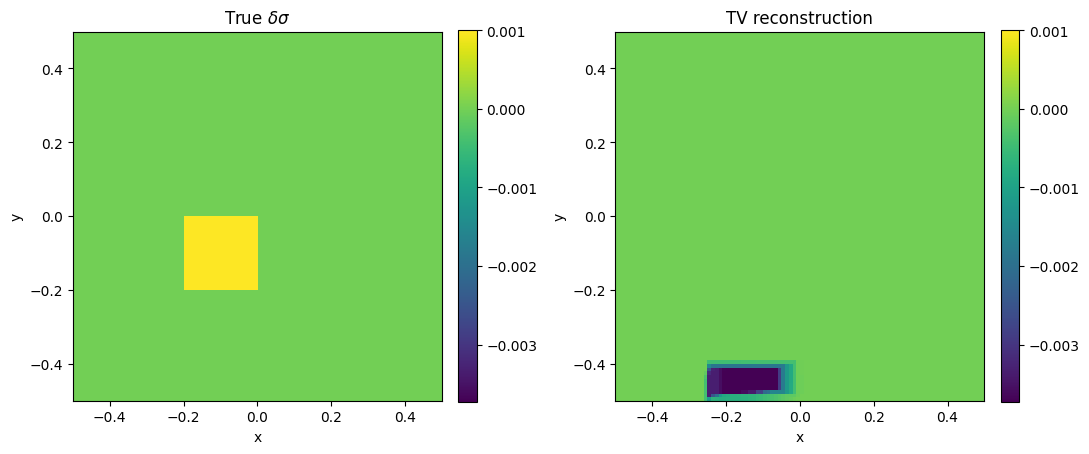

In [23]:
vmin = min(delta_sigma.min(), delta_sigma_tv.min())
vmax = max(delta_sigma.max(), delta_sigma_tv.max())

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, img, title in zip(
    axes,
    [delta_sigma, delta_sigma_tv],
    [r"True $\delta\sigma$", r"TV reconstruction"],
):
    im = ax.imshow(
        img,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        aspect="equal",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
A_np_check = np.asarray(A, dtype=np.float64)
A_t = torch.tensor(A_np_check, dtype=torch.float64, device="cuda" if torch.cuda.is_available() else "cpu")
condA = (torch.linalg.svdvals(A_t)[0] / (torch.linalg.svdvals(A_t)[-1] + 1e-12)).item()
print("cond(A) =", condA)


## Train $\xi$ (minimize $\kappa(\xi A)$)

Run the **sensitivity** cell above first so `A` has shape `(L², N²)` with `L = 2N-2`.
Trained arrays are saved to `4square_F.npy`, `4square_G.npy`, `4square_xi.npy` in the project folder.

In [ ]:
import sys
from pathlib import Path

# folder that contains optimize_xi_cond_pytorch.py (same dir as this notebook)
PROJECT_DIR = Path("/home/yaocai/eit").resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import torch
from optimize_xi_cond_pytorch import optimize_xi_cond, L_from_N

print("python:", sys.executable)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"

L = L_from_N(N)
A_np = np.asarray(A, dtype=np.float64)
assert A_np.shape == (L * L, N * N), (
    f"Expected A shape ({L*L}, {N*N}) for N={N}, got {A_np.shape}. "
    "Rebuild A from the sensitivity cell (grad u, grad v), not the FEM stiffness."
)

save_prefix = str(PROJECT_DIR / "4square")

xi_opt, history, F_opt, G_opt = optimize_xi_cond(
    A_np,
    c=20,
    N=N,
    steps=1000,
    lr=0.03,
    device=device,
    save_prefix=save_prefix,
    return_f_g=True,
)

print("final cond:", history[-1])
print("F_opt shape:", F_opt.shape)
print("G_opt shape:", G_opt.shape)
print("xi_opt shape:", xi_opt.shape)

# Optional explicit check of saved files:
F_saved = np.load(save_prefix + "_F.npy")
G_saved = np.load(save_prefix + "_G.npy")
xi_saved = np.load(save_prefix + "_xi.npy")
print("Saved F shape:", F_saved.shape)
print("Saved G shape:", G_saved.shape)
print("Saved xi shape:", xi_saved.shape)


In [15]:
np.set_printoptions(precision=4, suppress=True, linewidth=140)
print("F_opt first 3 rows:\n", F_opt[:3])
print("G_opt first 3 rows:\n", G_opt[:3])

F_opt first 3 rows:
 [[ 0.0587  0.2979 -0.0236 -0.6181 -0.0892 -0.1062 -0.0798 -0.3742 -0.1104 -0.3304  0.0019  0.1764 -0.2297 -0.0658  0.045   0.4626 -0.4828
   0.179  -0.1081 -0.6371  0.4347 -0.2901  0.008  -0.1895  0.1281  0.1143 -0.3349 -0.0184 -0.081  -0.4675 -0.3279 -0.2426 -0.1014  0.3522
   0.0685 -0.2702  0.1889 -0.4527  0.2635 -0.4514  0.4366  0.3863  0.2068 -0.2988 -0.0588  0.2494  0.2653  0.1799  0.2159 -0.0494  0.1882
  -0.1168 -0.0115 -0.2048 -0.2009 -0.1903 -0.1582  0.3306  0.3174 -0.5778  0.0564  0.1113 -0.2582 -0.0301 -0.4675  0.4459  0.0157  0.5581
   0.4355  0.0025 -0.1638  0.3755 -0.35    0.1324  0.1958 -0.276  -0.3259  0.1687  0.0678  0.0078  0.33    0.5508 -0.2353 -0.1448  0.3305
   0.402   0.2458 -0.052   0.4472 -0.0189 -0.2892  0.1425 -0.4459 -0.2521  0.1615  0.0651 -0.096   0.1045  0.2075  0.2132 -0.2741 -0.0453
   0.1047  0.4961 -0.1389  0.0283  0.0295  0.0869  0.1067 -0.4349  0.031   0.1648  0.1244  0.2984  0.1803  0.0315  0.0791  0.2876 -0.344
  -0.6252  0.1

In [16]:
import numpy as np

# Given:
# F_opt, G_opt from training, each shape (c, 2N-2)
# N=100, c=20 in your current run

c = F_opt.shape[0]
L = 2 * N - 2
m = 4 * N - 4

assert F_opt.shape == (c, L), f"F_opt shape mismatch: {F_opt.shape}, expected {(c, L)}"
assert G_opt.shape == (c, L), f"G_opt shape mismatch: {G_opt.shape}, expected {(c, L)}"

# New boundary-condition matrices for FEM
F_new = np.zeros((c, m), dtype=F_opt.dtype)
G_new = np.zeros((c, m), dtype=G_opt.dtype)

# Put trained F values on even indices: 0,2,4,...
F_new[:, 0::2] = F_opt

# Put trained G values on odd indices: 1,3,5,...
G_new[:, 1::2] = G_opt

print("F_new shape:", F_new.shape)  # should be (c, 4N-4)
print("G_new shape:", G_new.shape)  # should be (c, 4N-4)

# Optional checks
print("max |F_new odd entries|:", np.max(np.abs(F_new[:, 1::2])))   # should be 0
print("max |G_new even entries|:", np.max(np.abs(G_new[:, 0::2])))  # should be 0

F_new shape: (20, 396)
G_new shape: (20, 396)
max |F_new odd entries|: 0.0
max |G_new even entries|: 0.0


F_new shape: (20, 396)


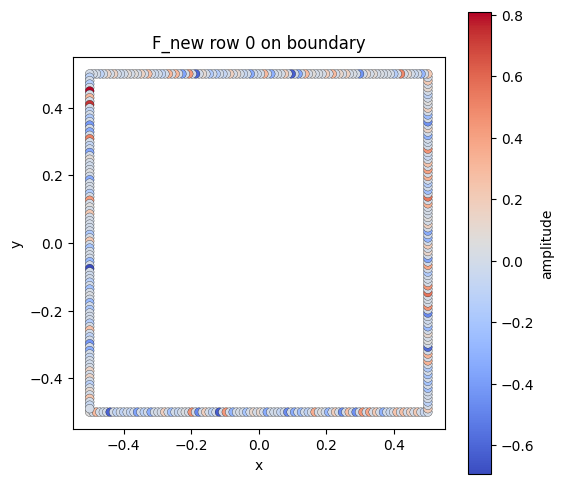

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# F_new shape should be (c, 4N-4)
print("F_new shape:", F_new.shape)

# choose which trained pattern to visualize
k = 0  # row index in [0, c-1]
f = F_new[k]  # length 4N-4

assert f.shape[0] == len(boundary_x) == len(boundary_y)

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(
    boundary_x, boundary_y,
    c=f,
    cmap="coolwarm",
    s=40,
    edgecolors="k",
    linewidths=0.2
)
ax.set_aspect("equal")
ax.set_xlim(-0.55, 0.55)
ax.set_ylim(-0.55, 0.55)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"F_new row {k} on boundary")
plt.colorbar(sc, ax=ax, label="amplitude")
plt.show()

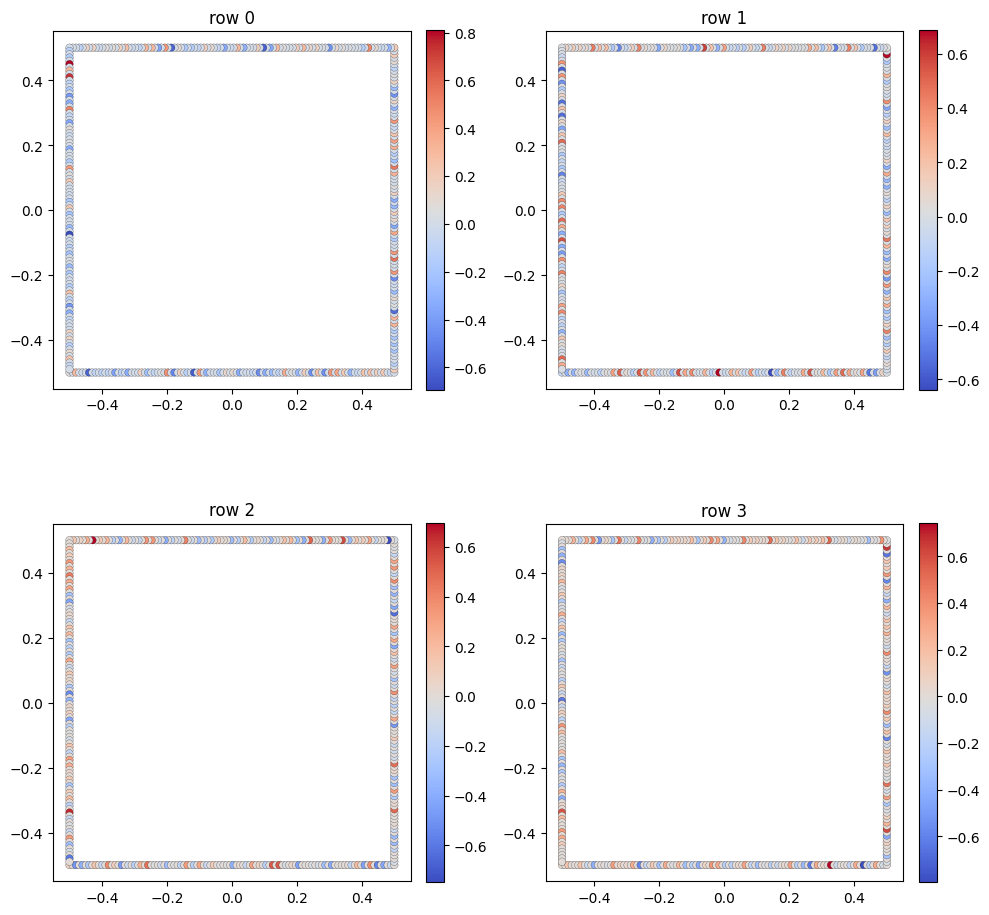

In [18]:
rows_to_plot = [0, 1, 2, 3]  # pick any
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for ax, k in zip(axes, rows_to_plot):
    f = F_new[k]
    sc = ax.scatter(boundary_x, boundary_y, c=f, cmap="coolwarm", s=30, edgecolors="k", linewidths=0.15)
    ax.set_aspect("equal")
    ax.set_xlim(-0.55, 0.55)
    ax.set_ylim(-0.55, 0.55)
    ax.set_title(f"row {k}")
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

A_w shape: (400, 10000)
b_w shape: (400,)
lambda: 1e-12
weighted residual ||A_w x - b_w|| / ||b_w||: 2.0160687888366486e-10
full residual ||A x - b|| / ||b||: 1.962901101521516
||x||: 0.004624488773219568


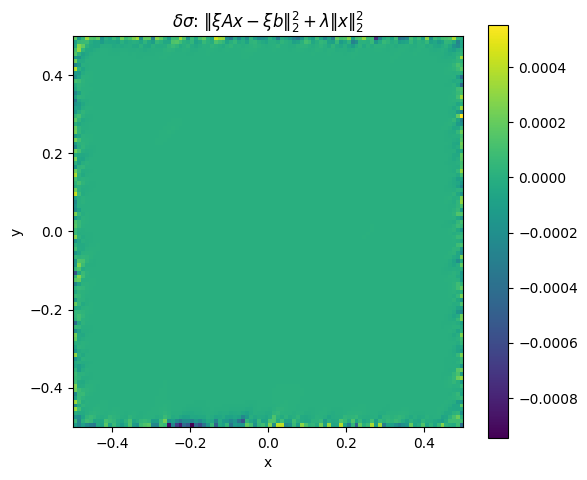

recon min / max: -0.0009461433529365231 0.0005538019967696416


In [32]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- xi from training ---
save_prefix = Path("/home/yaocai/eit/run1")
xi_opt = np.load(f"{save_prefix}_xi.npy")

# --- problem data ---
A_mat = np.asarray(A, dtype=np.float64)
b_vec = np.asarray(b, dtype=np.float64).ravel()
xi = np.asarray(xi_opt, dtype=np.float64)

L = 2 * N - 2
n = N * N

assert A_mat.shape == (L * L, n), f"A shape {A_mat.shape}, expected ({L*L}, {n})"
assert b_vec.shape == (L * L,), f"b shape {b_vec.shape}, expected ({L*L},)"
assert xi.shape[1] == L * L, f"xi shape {xi.shape}, expected (*, {L*L})"

# Weighted system: min ||A_w x - b_w||^2 + lam * ||x||^2
A_w = xi @ A_mat
b_w = xi @ b_vec

print("A_w shape:", A_w.shape)
print("b_w shape:", b_w.shape)

# Tikhonov L2 solve: (A_w^T A_w + lam I) x = A_w^T b_w
lam_l2 = 1e-12  # tune: larger -> smoother; smaller -> tighter fit

ATA = A_w.T @ A_w
ATb = A_w.T @ b_w
x_xi = np.linalg.solve(ATA + lam_l2 * np.eye(n), ATb)

# Diagnostics
res_w = A_w @ x_xi - b_w
res_full = A_mat @ x_xi - b_vec
print("lambda:", lam_l2)
print("weighted residual ||A_w x - b_w|| / ||b_w||:",
      np.linalg.norm(res_w) / (np.linalg.norm(b_w) + 1e-300))
print("full residual ||A x - b|| / ||b||:",
      np.linalg.norm(res_full) / (np.linalg.norm(b_vec) + 1e-300))
print("||x||:", np.linalg.norm(x_xi))

# Reconstruction
delta_sigma_xi = x_xi.reshape(N, N)

xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma_xi,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$: $\|\xi A x - \xi b\|_2^2 + \lambda\|x\|_2^2$")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("recon min / max:", float(delta_sigma_xi.min()), float(delta_sigma_xi.max()))

In [33]:
import numpy as np
from pathlib import Path

# xi from training
save_prefix = Path("/home/yaocai/eit/run1")
xi_opt = np.load(f"{save_prefix}_xi.npy")

A_mat = np.asarray(A, dtype=np.float64)
b_vec = np.asarray(b, dtype=np.float64).ravel()
xi = np.asarray(xi_opt, dtype=np.float64)

L = 2 * N - 2
n = N * N

A_w = xi @ A_mat   # (c^2, N^2)
b_w = xi @ b_vec   # (c^2,)

# Unregularized LS: min ||A_w x - b_w||_2^2
# Underdetermined (400 eqs, 10000 unknowns) -> minimum-norm least-squares solution
x_ls, residuals, rank, s = np.linalg.lstsq(A_w, b_w, rcond=None)

print("A_w shape:", A_w.shape)
print("lstsq rank:", rank)
print("||A_w x - b_w|| / ||b_w||:",
      np.linalg.norm(A_w @ x_ls - b_w) / (np.linalg.norm(b_w) + 1e-300))
print("||A x - b|| / ||b|| (full data):",
      np.linalg.norm(A_mat @ x_ls - b_vec) / (np.linalg.norm(b_vec) + 1e-300))

delta_sigma_ls = x_ls.reshape(N, N)

A_w shape: (400, 10000)
lstsq rank: 400
||A_w x - b_w|| / ||b_w||: 6.704478430891153e-15
||A x - b|| / ||b|| (full data): 1.9629020635384444


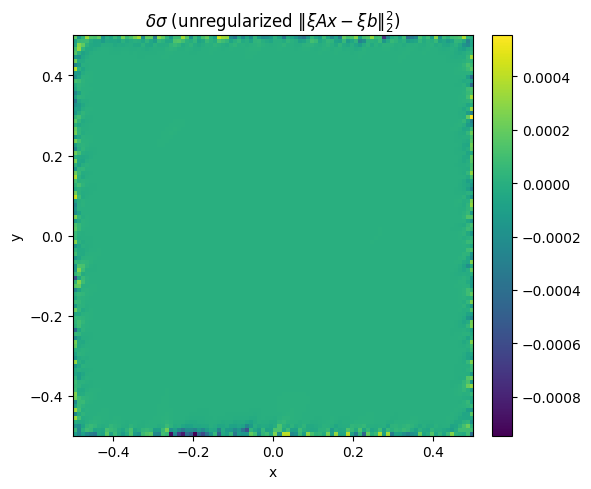

min / max: -0.0009461425730467806 0.0005538017129242003


In [34]:
import matplotlib.pyplot as plt
import numpy as np

xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5

# if you only have x_ls:
delta_sigma_ls = x_ls.reshape(N, N)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma_ls,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$ (unregularized $\|\xi A x - \xi b\|_2^2$)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("min / max:", float(delta_sigma_ls.min()), float(delta_sigma_ls.max()))

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse
from scipy.sparse.linalg import LinearOperator, cg

# --- load xi ---
save_prefix = Path("/home/yaocai/eit/run1")
xi_opt = np.load(f"{save_prefix}_xi.npy")

A_mat = np.asarray(A, dtype=np.float64)
b_vec = np.asarray(b, dtype=np.float64).ravel()
xi = np.asarray(xi_opt, dtype=np.float64)

n = N * N
A_w = xi @ A_mat
b_w = xi @ b_vec
Atb_w = A_w.T @ b_w

print("A_w shape:", A_w.shape)
print("b_w shape:", b_w.shape)


def make_gradient_operator(N):
    nrow = 2 * N * (N - 1)
    rows = np.empty(2 * nrow, dtype=np.int64)
    cols = np.empty(2 * nrow, dtype=np.int64)
    vals = np.empty(2 * nrow, dtype=np.float64)
    k = 0
    r = 0
    for jj in range(N):
        for ii in range(N - 1):
            k0 = ii * N + jj
            k1 = (ii + 1) * N + jj
            rows[k:k + 2] = r
            cols[k:k + 2] = [k1, k0]
            vals[k:k + 2] = [1.0, -1.0]
            k += 2
            r += 1
    for ii in range(N):
        for jj in range(N - 1):
            k0 = ii * N + jj
            k1 = ii * N + (jj + 1)
            rows[k:k + 2] = r
            cols[k:k + 2] = [k1, k0]
            vals[k:k + 2] = [1.0, -1.0]
            k += 2
            r += 1
    return sparse.csr_matrix((vals, (rows, cols)), shape=(nrow, n))


def soft_threshold(v, kappa):
    return np.sign(v) * np.maximum(np.abs(v) - kappa, 0.0)


# min 0.5||A_w x - b_w||^2 + lam_tv * ||D x||_1
lam_tv = 1e-4
rho = 1.0
max_admm = 100
tol_admm = 1e-4
cg_tol = 1e-5
cg_maxiter = 150

D = make_gradient_operator(N)
DtD = (D.T @ D).tocsr()

z = np.zeros(D.shape[0])
u = np.zeros_like(z)
x = np.zeros(n)

for it in range(max_admm):
    w = z - u
    rhs = Atb_w + rho * (D.T @ w)

    def apply_M(v):
        return A_w.T @ (A_w @ v) + rho * (DtD @ v)

    Mop = LinearOperator((n, n), matvec=apply_M, dtype=np.float64)
    x, info = cg(Mop, rhs, x0=x, rtol=cg_tol, atol=0.0, maxiter=cg_maxiter)

    Dx = D @ x
    z_old = z.copy()
    z = soft_threshold(Dx + u, lam_tv / rho)
    u = u + Dx - z

    r_primal = np.linalg.norm(Dx - z)
    r_dual = rho * np.linalg.norm(D.T @ (z - z_old))
    if r_primal < tol_admm and r_dual < tol_admm:
        print("ADMM converged at iter", it, "CG info:", info)
        break
else:
    print("ADMM stopped at max iter", max_admm, "CG info:", info)

delta_sigma_xi_tv = x.reshape(N, N)

print("weighted residual:",
      np.linalg.norm(A_w @ x - b_w) / (np.linalg.norm(b_w) + 1e-300))
print("full residual:",
      np.linalg.norm(A_mat @ x - b_vec) / (np.linalg.norm(b_vec) + 1e-300))


A_w shape: (400, 10000)
b_w shape: (400,)
ADMM converged at iter 1 CG info: 150
weighted residual: 0.9622450539499356
full residual: 0.9730157185271551


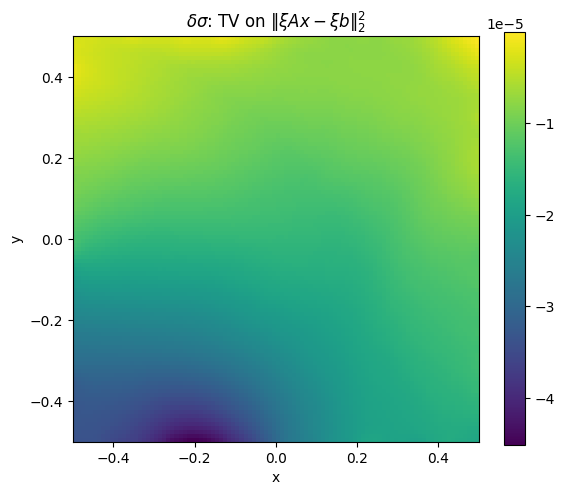

In [38]:
# plot
xmin, xmax, ymin, ymax = -0.5, 0.5, -0.5, 0.5
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    delta_sigma_xi_tv,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    cmap="viridis",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"$\delta\sigma$: TV on $\|\xi A x - \xi b\|_2^2$")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()